# linkgym quickstart

Create the `linkgym/LinkAdaptation-v0` environment, look at a few steps, follow Sionna's OLLA over one episode, and compare it with a random policy. Runs in well under a minute on a CPU.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch

import linkgym
from linkgym.baselines import OLLAPolicy

torch.set_num_threads(1)  # faster on the CPU for this simulator

## The environment

Each step chooses the MCS of one slot (action a selects MCS a + 3). The observation holds the last reports (wideband SINR, ACK/NACK, MCS), delayed by one slot. With `render_mode="ansi"`, `render()` returns a one-line summary of the last step.

In [2]:
env = gym.make("linkgym/LinkAdaptation-v0", snr_db=15.0, render_mode="ansi")
obs, info = env.reset(seed=0)
print("observation shape:", obs.shape, "| action space:", env.action_space)
for _ in range(5):
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
    print(env.render(), f"| reward {reward:.3f}")

observation shape: (12,) | action space: Discrete(26)
slot     0 | MCS 13 | ACK  |  14344 bits | running TBLER 0.000 | reward 0.341
slot     1 | MCS 17 | ACK  |  18960 bits | running TBLER 0.000 | reward 0.451
slot     2 | MCS 21 | ACK  |  27144 bits | running TBLER 0.000 | reward 0.646
slot     3 | MCS  3 | ACK  |   3752 bits | running TBLER 0.000 | reward 0.089
slot     4 | MCS  6 | ACK  |   6528 bits | running TBLER 0.000 | reward 0.155


## OLLA over one episode

OLLA chooses the MCS from the latest report and adjusts an SINR offset from the ACK/NACK feedback. `info` returns the report that entered the observation and the outcome of the slot.

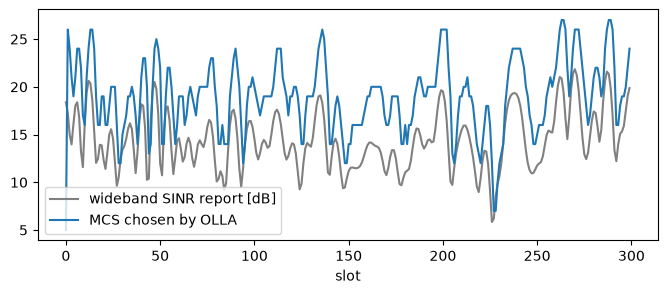

observed TBLER over these slots: 0.110


In [3]:
policy = OLLAPolicy(bler_target=0.1)
obs, info = env.reset(seed=1000)
policy.reset()
sinr_db, mcs, acks = [], [], []
for _ in range(300):
    obs, reward, terminated, truncated, info = env.step(policy.act(obs, info))
    sinr_db.append(info["report"]["sinr_wideband_db"])
    mcs.append(info["mcs"])
    acks.append(info["ack"])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(sinr_db, color="gray", label="wideband SINR report [dB]")
ax.plot(mcs, color="C0", label="MCS chosen by OLLA")
ax.set_xlabel("slot")
ax.legend()
plt.show()
print(f"observed TBLER over these slots: {1 - np.mean(acks):.3f}")

## Evaluation

`linkgym.evaluate` runs a policy through `gymnasium.make` on the given seeds; any object with `act(obs, info)` works. With the same seeds, every policy faces the same channel and the same ACK draws.

OLLA (target 0.1)  goodput  37.04 Mbit/s   TBLER 0.103
random MCS         goodput  18.61 Mbit/s   TBLER 0.330


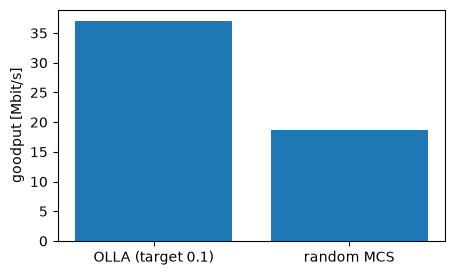

In [4]:
class RandomPolicy:
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)

    def act(self, obs, info):
        return int(self.rng.integers(26))


seeds = [1000, 1001]
results = {
    "OLLA (target 0.1)": linkgym.evaluate(OLLAPolicy(bler_target=0.1), seeds=seeds),
    "random MCS": linkgym.evaluate(RandomPolicy(), seeds=seeds),
}
for name, r in results.items():
    goodput, tbler = r["goodput_mbps"]["mean"], r["observed_tbler"]["mean"]
    print(f"{name:18s} goodput {goodput:6.2f} Mbit/s   TBLER {tbler:.3f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(list(results), [r["goodput_mbps"]["mean"] for r in results.values()])
ax.set_ylabel("goodput [Mbit/s]")
plt.show()

## Next steps

- Train PPO: see the README quickstart or `examples/train_ppo.py`.
- Observation layout, timing and scenario fields: `docs/environment.md`.
- Baselines and results: `docs/results/m3/README.md`.